## 1. Carregamento

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/vgsales.csv")

print(df.shape)
print(df.dtypes)
df.head(10)

(16598, 11)
Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [6]:
print(df.isnull().sum())

print(df['Year'].unique())
print(df['Year'].describe())

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
[2006. 1985. 2008. 2009. 1996. 1989. 1984. 2005. 1999. 2007. 2010. 2013.
 2004. 1990. 1988. 2002. 2001. 2011. 1998. 2015. 2012. 2014. 1992. 1997.
 1993. 1994. 1982. 2003. 1986. 2000.   nan 1995. 2016. 1991. 1981. 1987.
 1980. 1983. 2020. 2017.]
count    16327.000000
mean      2006.406443
std          5.828981
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2020.000000
Name: Year, dtype: float64


## 2. Limpeza

In [7]:
df_clean = df.copy()
df_clean = df_clean.dropna(subset=['Year'])

df_clean['Year'] = df_clean['Year'].astype(int)

df_clean = df_clean[df_clean['Year'] <= 2016]

print(df_clean.shape)

(16323, 11)


In [ ]:
# Unifica publishers que são a mesma empresa
publisher_map = {
    'SquareSoft': 'Square Enix',
    'Enix Corporation': 'Square Enix'
}
df_clean['Publisher'] = df_clean['Publisher'].replace(publisher_map)

## 3. Análise Exploratória

### 3.1 Vendas por Gênero

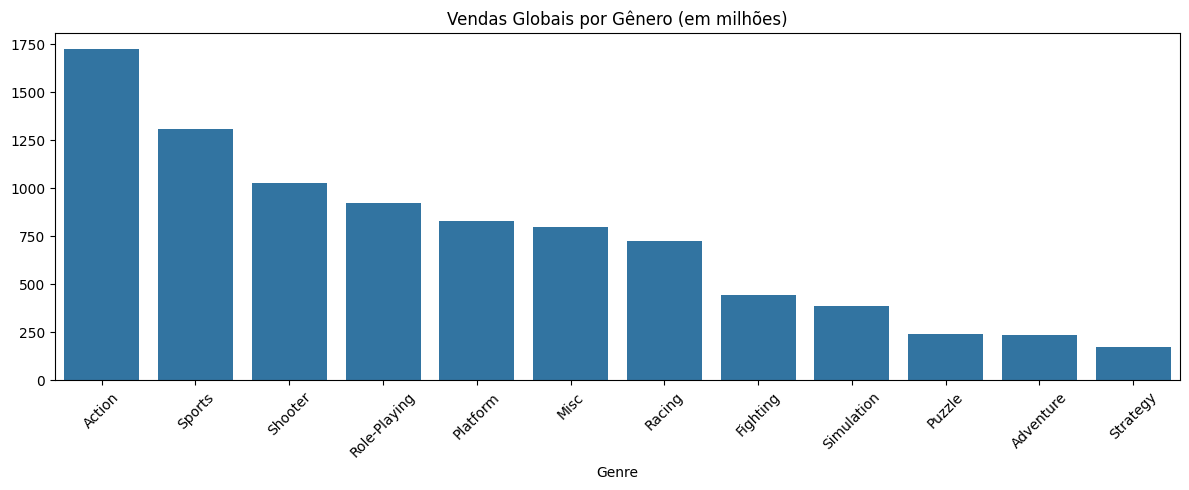

In [ ]:
genero_vendas = df_clean.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=genero_vendas.index, y=genero_vendas.values)
plt.title('Vendas Globais por Gênero (em milhões)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
jogos_por_genero = df_clean.groupby('Genre')['Name'].count()
media_vendas = df_clean.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)
print(media_vendas)

Genre
Platform        0.946518
Shooter         0.800468
Role-Playing    0.628863
Racing          0.592798
Sports          0.568247
Fighting        0.531160
Action          0.529788
Misc            0.466444
Simulation      0.458671
Puzzle          0.424203
Strategy        0.258465
Adventure       0.184013
Name: Global_Sales, dtype: float64


### 3.2 Comparativos Regionais

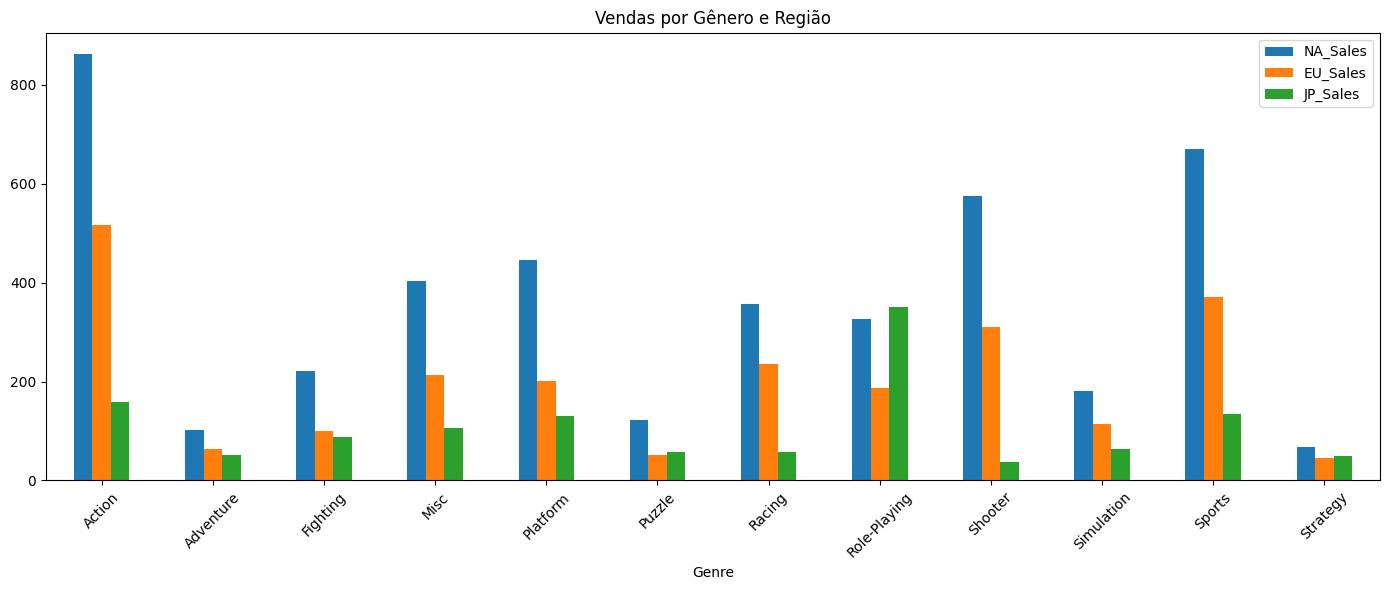

In [11]:
regioes = ['NA_Sales', 'EU_Sales', 'JP_Sales']
vendas_regiao = df_clean.groupby('Genre')[regioes].sum()

vendas_regiao.plot(kind='bar', figsize=(14,6))
plt.title("Vendas por Gênero e Região")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Tendência Temporal

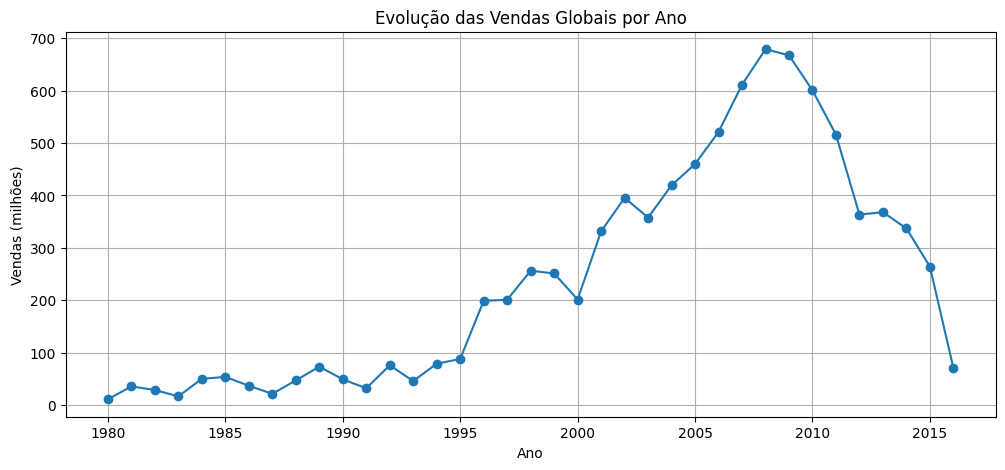

In [12]:
vendas_ano = df_clean.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(12, 5))
plt.plot(vendas_ano.index, vendas_ano.values, marker='o')
plt.title("Evolução das Vendas Globais por Ano")
plt.xlabel("Ano")
plt.ylabel("Vendas (milhões)")
plt.grid()
plt.show()

#### 3.3.1 Tentando entender a queda de vendas

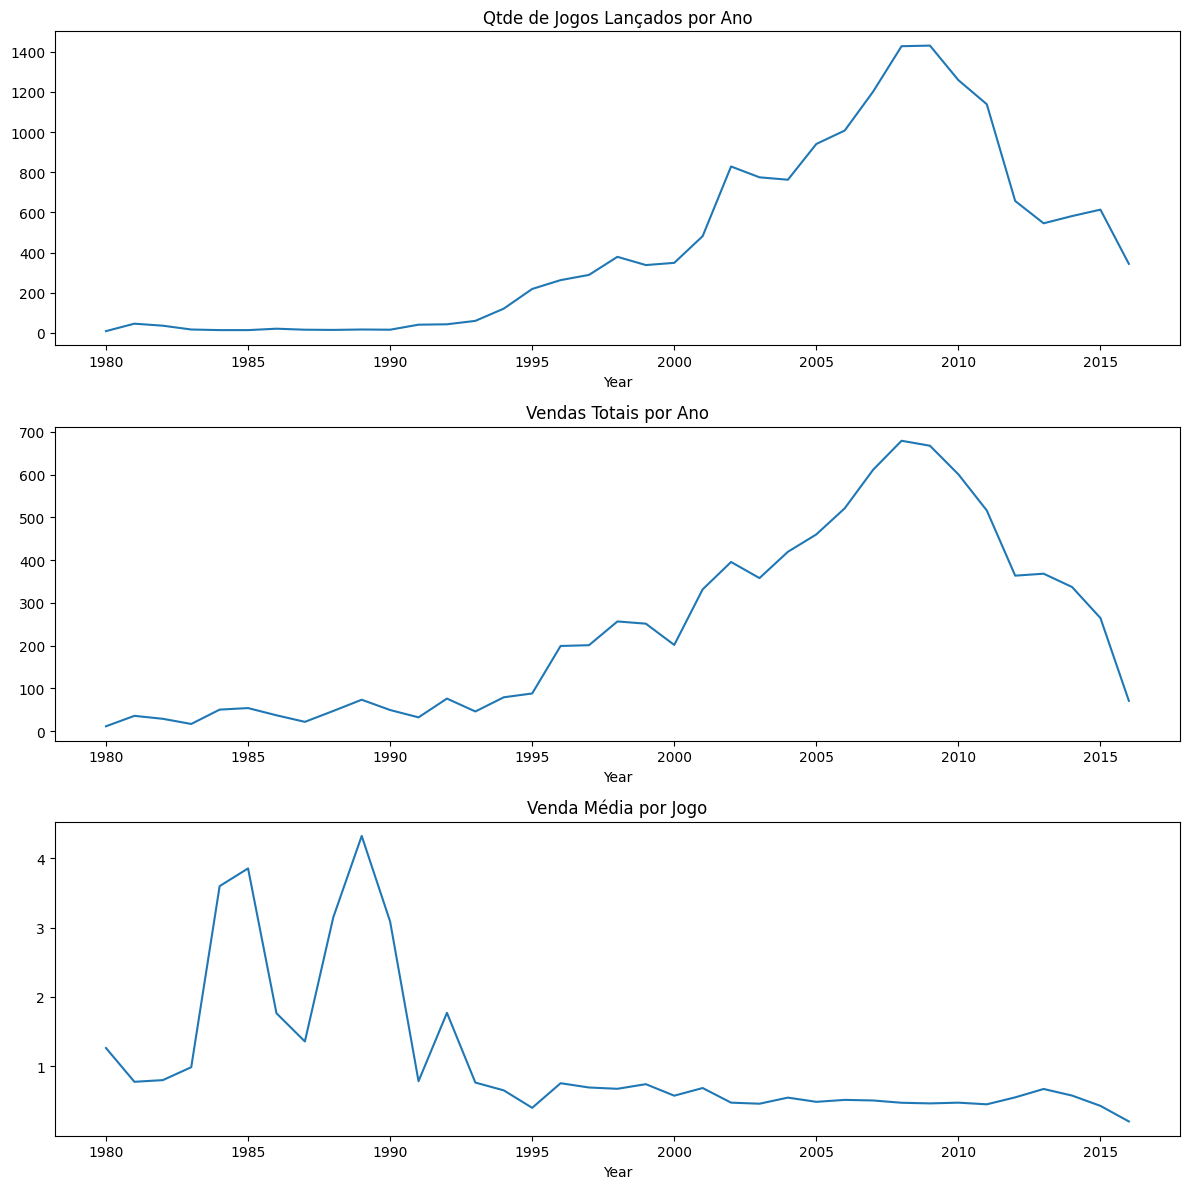

In [13]:
jogos_por_ano = df_clean.groupby('Year')['Name'].count()
media_por_jogo = vendas_ano / jogos_por_ano

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
jogos_por_ano.plot(ax=axes[0], title='Qtde de Jogos Lançados por Ano')
vendas_ano.plot(ax=axes[1], title='Vendas Totais por Ano')
media_por_jogo.plot(ax=axes[2], title='Venda Média por Jogo')
plt.tight_layout()
plt.show()

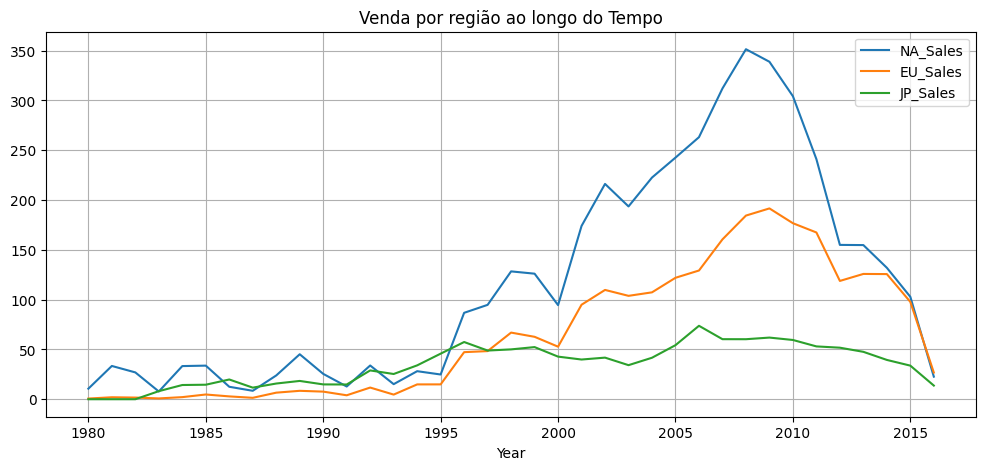

In [14]:
vendas_regiao_ano = df_clean.groupby('Year')[['NA_Sales' , 'EU_Sales', 'JP_Sales']].sum()
vendas_regiao_ano.plot(figsize=(12, 5), title= "Venda por região ao longo do Tempo")
plt.grid(True)
plt.show()

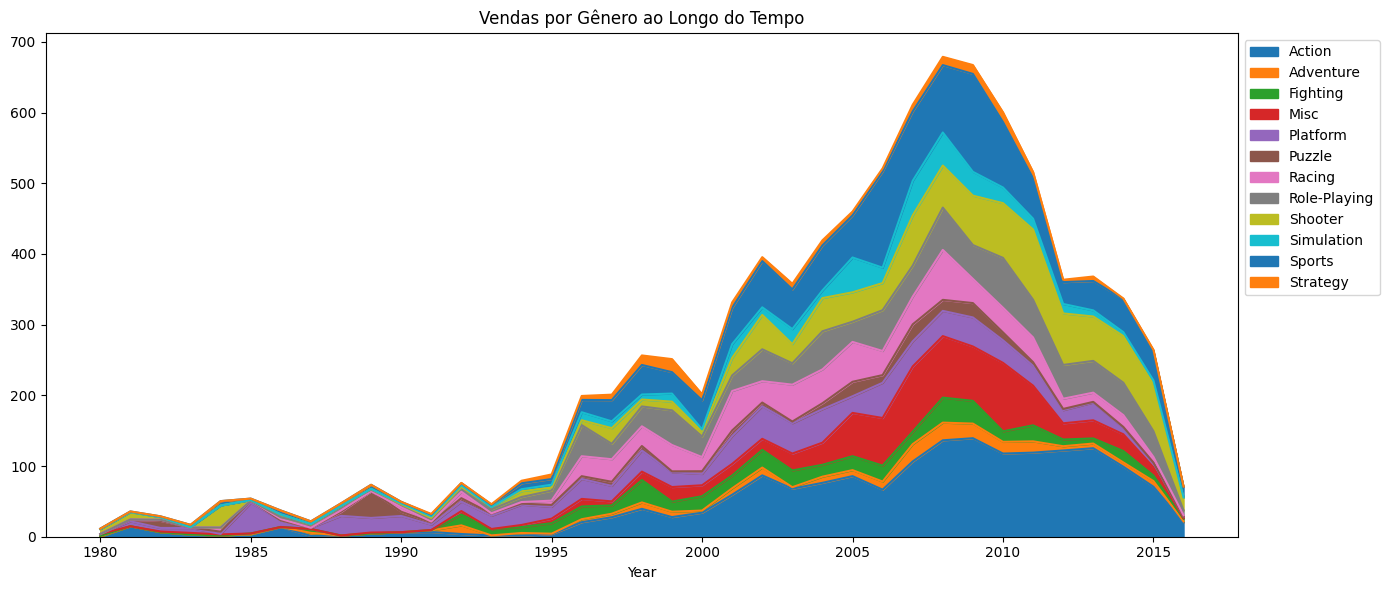

In [15]:
vendas_genero_ano = df_clean.groupby(['Year', 'Genre'])['Global_Sales'].sum().unstack()
vendas_genero_ano.plot(figsize=(14, 6), title='Vendas por Gênero ao Longo do Tempo', kind='area')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

##### Action e Sports apresentam grande dominancia, Action ainda se mantem um pouco na queda

### 3.4 Concentração de mercado

In [16]:
top10 = df_clean.nlargest(10, 'Global_Sales')['Global_Sales'].sum()
total = df_clean['Global_Sales'].sum()
print(f'Top 10 jogos = {top10/total*100:.1f}% das vendas globais')

top_publishers = df_clean.groupby('Publisher')['Global_Sales'].sum()
top10_pub = top_publishers.nlargest(10).sum()
print(f'Top 10 Publishers = {top10_pub/total*100:.1f}% das vendas globais')

Top 10 jogos = 4.2% das vendas globais
Top 10 Publishers = 70.5% das vendas globais


### 3.5 Dominancia por Região

In [17]:
# Quais publishers dominam RPG no Japão? RPG tem a maior venda
jp_rpg = df_clean[(df_clean['Genre'] == 'Role-Playing') & (df_clean['JP_Sales'] > 0)]
jp_rpg.groupby('Publisher')['JP_Sales'].sum().sort_values(ascending=False).head(10)

Publisher
Nintendo                        101.95
Square Enix                      41.44
SquareSoft                       36.45
Enix Corporation                 31.26
Namco Bandai Games               28.17
Capcom                           22.75
Sony Computer Entertainment      16.08
Sega                              8.00
Atlus                             5.93
Konami Digital Entertainment      5.69
Name: JP_Sales, dtype: float64

In [ ]:
# Revendo dominancia dos publishers
jp_rpg = df_clean[(df_clean['Genre'] == 'Role-Playing') & (df_clean['JP_Sales'] > 0)]
jp_rpg.groupby('Publisher')['JP_Sales'].sum().sort_values(ascending=False).head(10)

Publisher
Square Enix                     109.15
Nintendo                        101.95
Namco Bandai Games               28.17
Capcom                           22.75
Sony Computer Entertainment      16.08
Sega                              8.00
Atlus                             5.93
Konami Digital Entertainment      5.69
Level 5                           5.68
Nippon Ichi Software              4.43
Name: JP_Sales, dtype: float64

In [19]:
na_action = df_clean[(df_clean['Genre'] == 'Action') & ( df_clean['NA_Sales'] > 0)]
na_action.groupby('Publisher')['NA_Sales'].sum().sort_values(ascending=False).head(10)

Publisher
Take-Two Interactive                      101.45
Activision                                 86.83
Ubisoft                                    69.38
Nintendo                                   63.49
THQ                                        54.31
Electronic Arts                            54.23
Warner Bros. Interactive Entertainment     51.90
Sony Computer Entertainment                46.09
Capcom                                     35.93
LucasArts                                  34.07
Name: NA_Sales, dtype: float64

In [20]:
eu_action = df_clean[(df_clean['Genre'] == 'Action') & ( df_clean['EU_Sales'] > 0)]
eu_action.groupby('Publisher')['EU_Sales'].sum().sort_values(ascending=False).head(10)

Publisher
Take-Two Interactive                      70.44
Ubisoft                                   54.10
Electronic Arts                           43.92
Warner Bros. Interactive Entertainment    40.43
Activision                                39.99
Sony Computer Entertainment               29.84
Nintendo                                  29.02
THQ                                       24.83
Eidos Interactive                         22.62
Capcom                                    20.36
Name: EU_Sales, dtype: float64

In [ ]:
jp_rpg.groupby('Platform')['JP_Sales'].sum().sort_values(ascending=False).head(10)

Platform
DS      54.29
PS      40.95
3DS     39.58
GB      34.55
SNES    33.76
PS2     32.85
PSP     30.78
GBA     21.21
PS3     16.76
NES     16.11
Name: JP_Sales, dtype: float64

In [22]:
na_action.groupby('Platform')['NA_Sales'].sum().sort_values(ascending=False).head(10)

Platform
X360    139.62
PS2     127.71
PS3     119.82
Wii      65.59
DS       65.58
PS       62.15
GBA      36.24
XB       33.19
PS4      29.70
GC       25.66
Name: NA_Sales, dtype: float64

In [23]:
eu_action.groupby('Platform')['EU_Sales'].sum().sort_values(ascending=False).head(10)

Platform
PS3     109.26
X360     75.85
PS2      71.34
PS       44.63
PS4      38.19
Wii      30.58
DS       26.70
PC       17.34
PSP      16.95
GBA      14.36
Name: EU_Sales, dtype: float64

## 4. Conclusões

1. **Gênero para investir:** 
   - JP: Role-Playing, com foco na Square Enix e Nintendo
   - NA: Action e Shooter lideram em volume; Shooter tem melhor 
     retorno médio por jogo
   - EU: Action e Shooter com perfil similar à NA; Sports também 
     relevante
2. **Plataforma com melhor histórico:** 
    - JP: DS 
    - NA: X360, PS2 e PS3 
    - EU: PS3, X360, PS2
3. **Diferença e Semelhança regional mais relevante:** EU e NA tem semelhanças nas plataformas em destaque, sendo elas, X360, PS2 e PS3. Outra semelhança de ambas seria no gênero para investir, sendo Action. Já o Japão, é apenas bem mais focado em RP gerando outra área para investimento.
4. **Tendência de mercado:** As vendas estão caindo drásticamente comparando entre 2000 e 2015, podemos observar a queda da venda média por jogo, correlacionada por uma diminuição nas publicações de jogos, com menos jogos lançando, menor as vendas.
5. **Limitações dessa análise:** O dataset não possui dados pós-2016 nem informações de receita digital, o que impede determinar se a queda reflete mudança de comportamento do consumidor (migração para mobile e distribuição digital) ou subnotificação do próprio dataset.
6. **Concentração de mercado:** O mercado é dominado por poucas empresas (top 10 publishers = 70.5% das vendas), porém sem dependência de títulos isolados (top 10 jogos = apenas 4.2% do total). Isso indica que publishers líderes constroem vantagem competitiva através de **catálogo**, não de um único blockbuster — o que eleva a barreira de entrada para novos competidores.

## 5. Load - Parquet

In [24]:
output_path = Path('../data/output/vgsales.parquet')
output_path.parent.mkdir(parents=True, exist_ok=True)

df_clean.to_parquet(output_path, index=False)
size_mb = output_path.stat().st_size / (1024 * 1024)
print(f"=== PARQUET ===")
print(f"Arquivo: {output_path}")
print(f"Tamanho: {size_mb:.1f} MB")

=== PARQUET ===
Arquivo: ..\data\output\vgsales.parquet
Tamanho: 0.4 MB


In [25]:
# Validação: ler de volta o Parquet e conferir
df_parquet = pd.read_parquet(output_path)
print(f"=== VALIDAÇÃO ===")
print(f"Registros no Parquet: {len(df_parquet):,}")
print(f"Registros esperados:  {len(df_clean):,}")
print(f"Match: {'OK' if len(df_parquet) == len(df_clean) else 'ERRO'}")
print(f"\nColunas: {list(df_parquet.columns)}")
df_parquet.head()

=== VALIDAÇÃO ===
Registros no Parquet: 16,323
Registros esperados:  16,323
Match: OK

Colunas: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
